# Bài tập về nhà Buổi 2:Module 1- Toán học trong AI 

- **Học viên:** Trần Thị Kiều My
- **Môn học:** Python & Machine Learning 

## Phần 1: Thống kê mô tả và đặc trưng

In [21]:
import seaborn as sns
import pandas as pd

iris_df = sns.load_dataset("iris")

print("5 dòng đầu của dữ liệu Iris:")
print(iris_df.head())

so_dong, so_cot = iris_df.shape
print(f"\nSố dòng: {so_dong}, Số cột: {so_cot}")

print("\nKiểu dữ liệu của từng cột")
print(iris_df.dtypes)

5 dòng đầu của dữ liệu Iris:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng: 150, Số cột: 5

Kiểu dữ liệu của từng cột
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [22]:

chi_so_numeric = iris_df.select_dtypes(include=['float64'])

thong_ke_co_ban = chi_so_numeric.describe()

mode_values = chi_so_numeric.mode().iloc[0]
variance_values = chi_so_numeric.var()

Q1 = chi_so_numeric.quantile(0.25)
Q3 = chi_so_numeric.quantile(0.75)
iqr_values = Q3 - Q1

print("\nThống kê cơ bản (Mean, Median, Std, Min, Max, Q1, Q3)")
print(thong_ke_co_ban)
print("\nMode")
print(mode_values)
print("\nPhương sai")
print(variance_values)
print("\nIQR")
print(iqr_values)


Thống kê cơ bản (Mean, Median, Std, Min, Max, Q1, Q3)
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Mode
sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64

Phương sai
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

IQR
sepal_length    1.3
sepal_width     0.5
petal_length    3.5
petal_width     1.5
dtype: float64


In [23]:

thong_ke_theo_loai_mean = iris_df.groupby('species').mean()
thong_ke_theo_loai_std = iris_df.groupby('species').std()

print("\nTrung bình các biến theo loài")
print(thong_ke_theo_loai_mean)
print("\nĐộ lệch chuẩn các biến theo loài")
print(thong_ke_theo_loai_std)


Trung bình các biến theo loài
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

Độ lệch chuẩn các biến theo loài
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


**Nhận xét:**
- Tập dữ liệu bao gồm 150 mẫu với 5 đặc trưng, trong đó 4 đặc trưng là dữ liệu số (float64) mô tả kích thước hoa và 1 đặc trưng phân loại (species).

- Qua các chỉ số mean và std,các biến có độ phân tán khác nhau. Đặc biệt, khi nhóm theo species, loài Iris setosa cho thấy sự khác biệt rõ rệt về giá trị trung bình ở các biến độ dài và rộng của cánh hoa so với hai loài còn lại.

## Phần 2: Phân phối xác suất

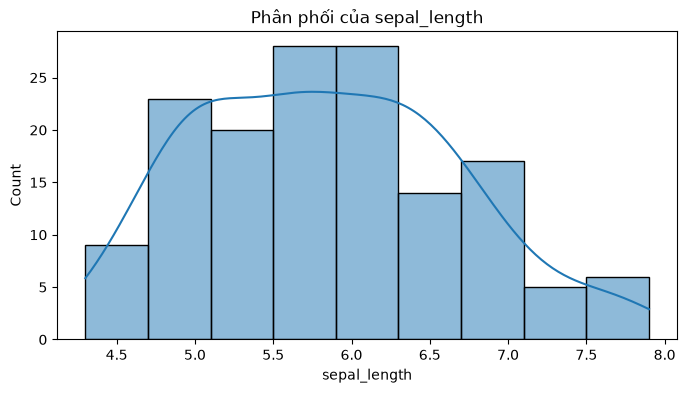

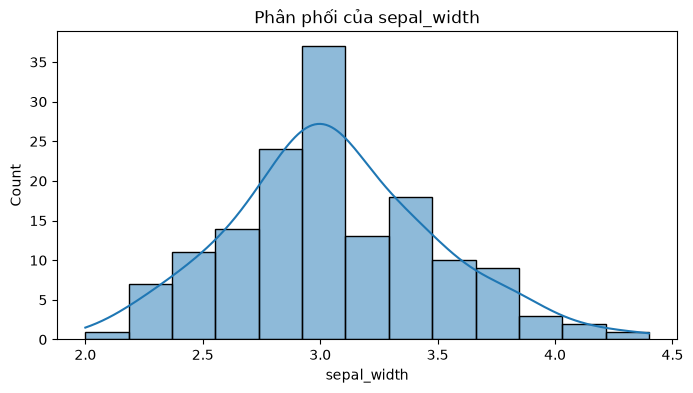

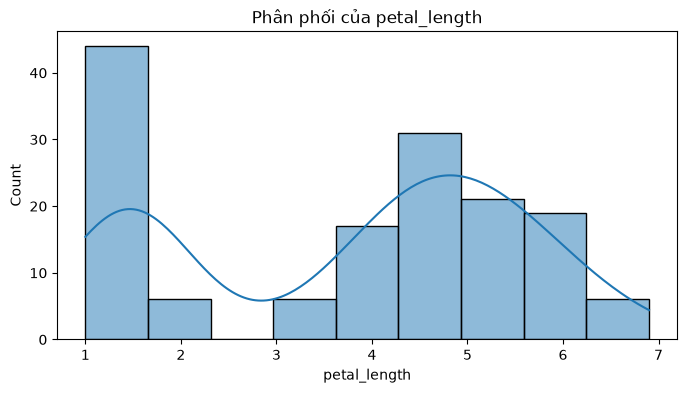

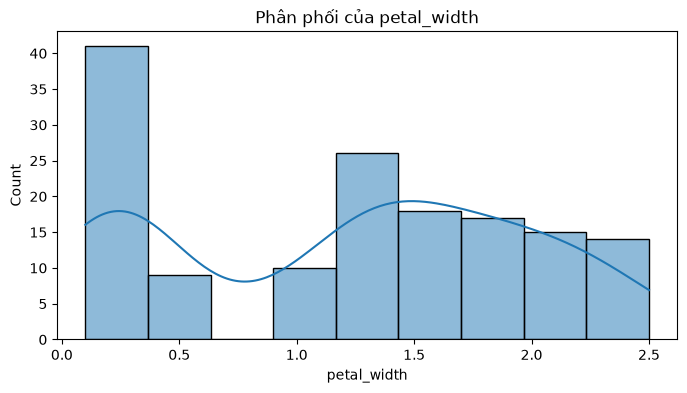

In [24]:

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = iris_df.select_dtypes(include=['float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=iris_df, x=col, kde=True)
    plt.title(f'Phân phối của {col}')
    plt.show()

**Nhận xét:**
Về phân phối (Histogram & KDE): Các biến số có dạng phân phối gần với phân phối chuẩn, một số biến có độ lệch nhẹ. Điều này cho thấy dữ liệu tập trung nhiều quanh giá trị trung bình.

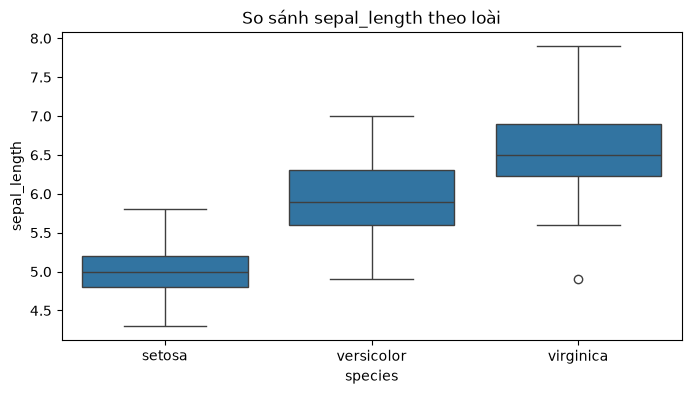

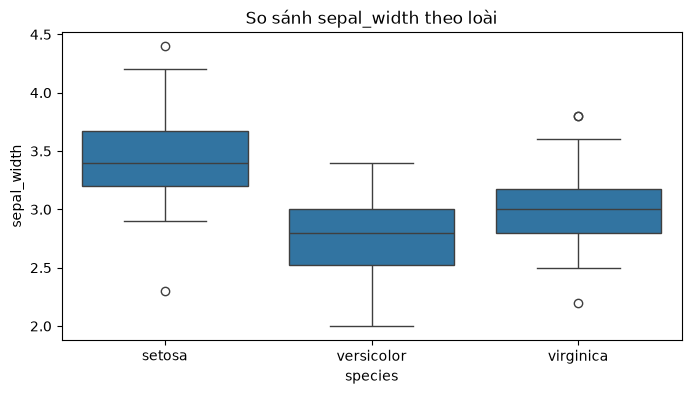

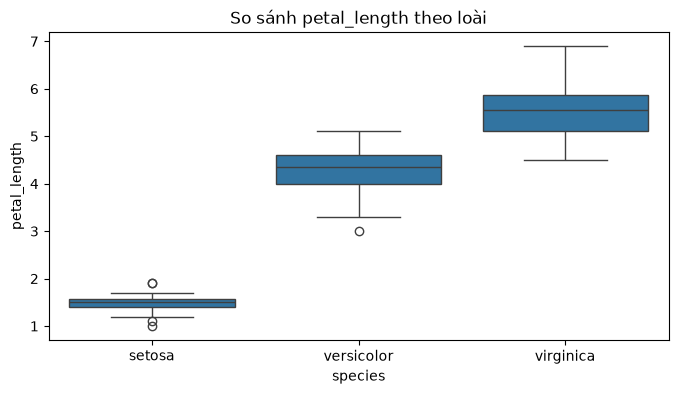

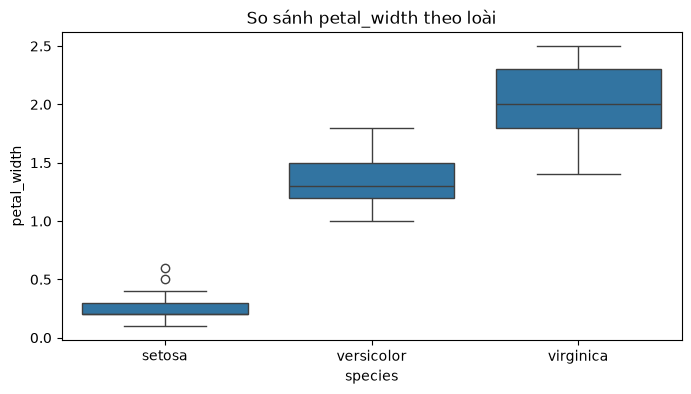

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=iris_df, x='species', y=col)
    plt.title(f'So sánh {col} theo loài')
    plt.show()

**Nhận xét:**
Về so sánh nhóm (Boxplot): Các hộp (box) của các loài hoa không chồng lấn lên nhau ở nhiều biến, chứng tỏ các đặc trưng này rất tốt để phân loại các loài hoa.

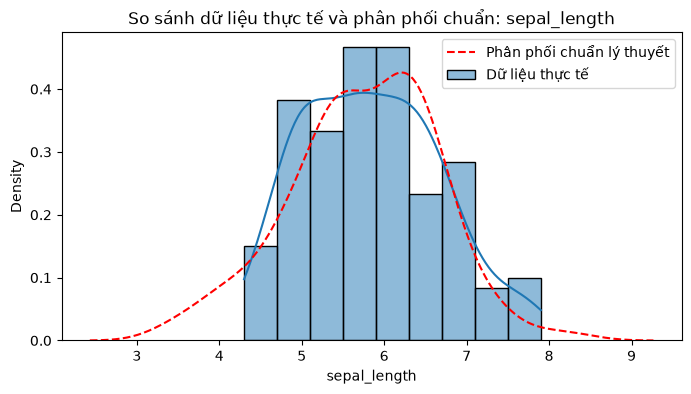

In [26]:
import numpy as np

col_name = 'sepal_length'
mean_val = iris_df[col_name].mean()
std_val = iris_df[col_name].std()

sampled_data = np.random.normal(mean_val, std_val, size=len(iris_df))

plt.figure(figsize=(8, 4))
sns.histplot(iris_df[col_name], kde=True, label='Dữ liệu thực tế', stat="density")
sns.kdeplot(sampled_data, color='red', label='Phân phối chuẩn lý thuyết', linestyle='--')
plt.legend()
plt.title(f'So sánh dữ liệu thực tế và phân phối chuẩn: {col_name}')
plt.show()

**Nhận xét:**
Về mô phỏng: Kết quả mô phỏng từ np.random.normal cho thấy đường cong lý thuyết khá khớp với dữ liệu thực tế, khẳng định tính chất tiệm cận phân phối chuẩn của các đặc trưng trên dataset Iris.

## Phần 3: Phân tích đa biến và tương quan

In [27]:

cov_matrix = iris_df.cov(numeric_only=True)
print("Ma trận hiệp phương sai")
print(cov_matrix)

corr_matrix = iris_df.corr(numeric_only=True)
print("\nMa trận tương quan")
print(corr_matrix)

Ma trận hiệp phương sai
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

Ma trận tương quan
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


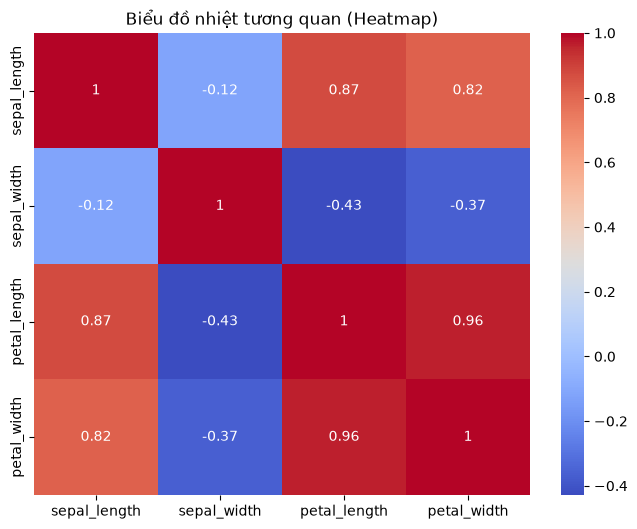

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Biểu đồ nhiệt tương quan (Heatmap)')
plt.show()

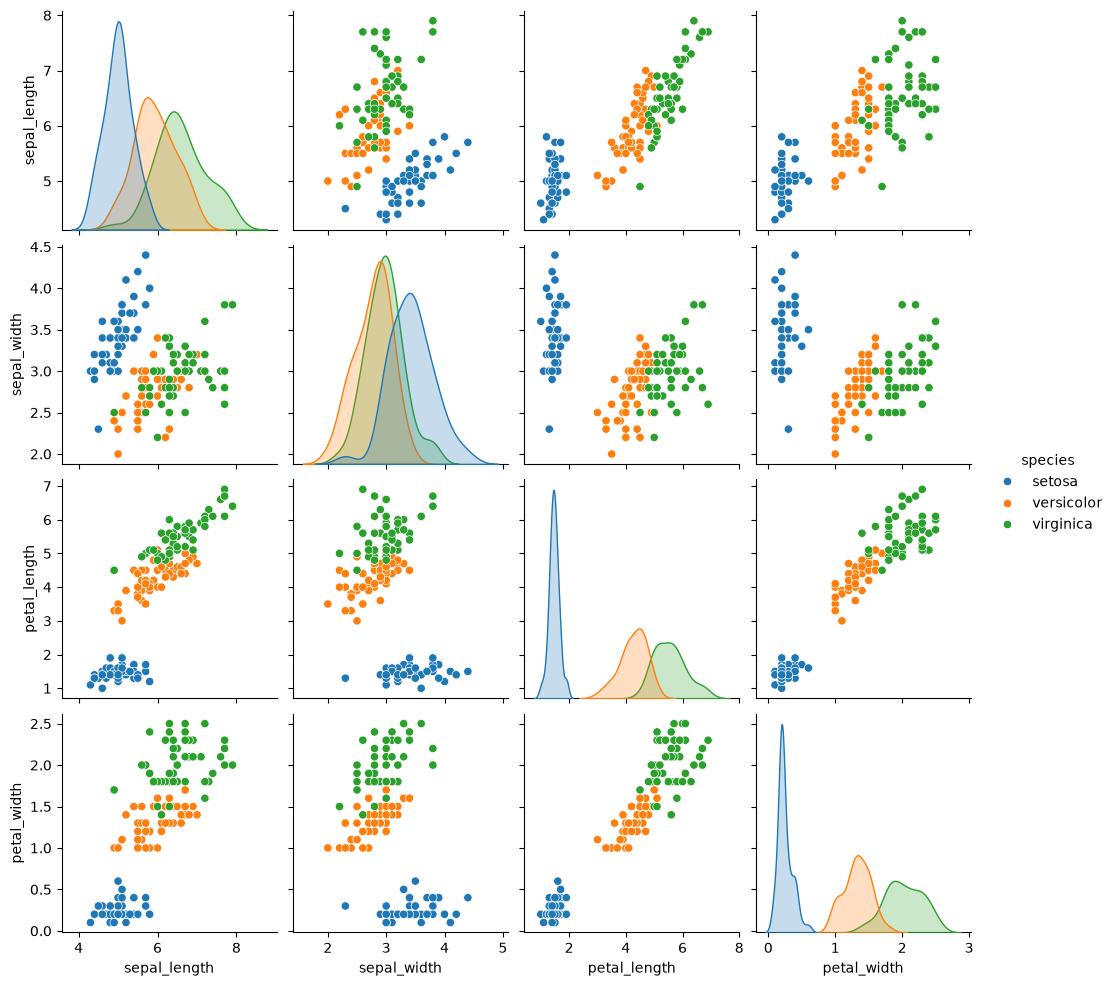

In [29]:

sns.pairplot(iris_df, hue='species')
plt.show()

**Nhận xét:**
Tương quan: Quan sát Heatmap,các biến số có tương quan thuận mạnh (hệ số gần 1), đặc biệt là giữa chiều dài và chiều rộng cánh hoa.

Đa cộng tuyến: Một số cặp biến có tương quan rất cao (> 0.9), đây là dấu hiệu của hiện tượng đa cộng tuyến.

Pairplot: Các cụm dữ liệu phân tách rất rõ ràng khi tô màu theo loài (species), xác nhận khả năng phân biệt loài hoa dựa trên các đặc trưng đã chọn là rất cao.

In [30]:

P_B = 0.01          
P_pos_givenB = 0.99 
P_pos_givenNB = 0.05 

P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)

P_B_given_pos = (P_pos_givenB * P_B) / P_pos

print(f"Xác suất mắc bệnh khi có kết quả dương tính: {round(P_B_given_pos, 4)}")

Xác suất mắc bệnh khi có kết quả dương tính: 0.1667


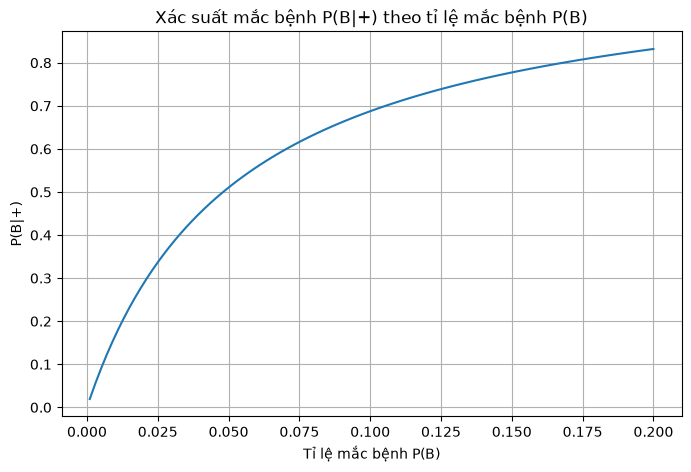

In [31]:
import numpy as np
import matplotlib.pyplot as plt

p_b_values = np.linspace(0.001, 0.2, 100)
p_b_given_pos_values = []

for p_b in p_b_values:
    p_pos = P_pos_givenB * p_b + P_pos_givenNB * (1 - p_b)
    p_b_given_pos = (P_pos_givenB * p_b) / p_pos
    p_b_given_pos_values.append(p_b_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(p_b_values, p_b_given_pos_values)
plt.title("Xác suất mắc bệnh P(B|+) theo tỉ lệ mắc bệnh P(B)")
plt.xlabel("Tỉ lệ mắc bệnh P(B)")
plt.ylabel("P(B|+)")
plt.grid(True)
plt.show()

**Nhận xét:**
Với tỉ lệ mắc bệnh trong dân số là 1%, xác suất thực sự mắc bệnh khi có kết quả dương tính là 0.1667

Kết quả này thấp hơn nhiều so với kỳ vọng (99%) là do tỉ lệ mắc bệnh trong dân số quá thấp. Khi bệnh hiếm, số lượng dương tính giả (dù tỉ lệ thấp 5%) vẫn chiếm tỉ trọng lớn trong tổng số các ca dương tính, dẫn đến độ tin cậy của xét nghiệm bị giảm đi đáng kể.

In [32]:

word_probs = {
    'sale': {'spam': 0.8, 'ham': 0.1},
    'win': {'spam': 0.7, 'ham': 0.05},
    'prize': {'spam': 0.6, 'ham': 0.02},
    'meeting': {'spam': 0.01, 'ham': 0.5},
    'hello': {'spam': 0.02, 'ham': 0.4}
}

P_spam = 0.3
P_ham = 0.7

def calculate_spam_probability(email_words):
    p_words_given_spam = P_spam 
    p_words_given_ham = P_ham
    
    for word in email_words:
        if word in word_probs:
            p_words_given_spam *= word_probs[word]['spam']
            p_words_given_ham *= word_probs[word]['ham']
    
    total_prob = p_words_given_spam + p_words_given_ham
    return p_words_given_spam / total_prob

email1 = ['sale', 'win'] 
email2 = ['hello', 'meeting'] 
email3 = ['sale', 'hello'] 

print(f"Xác suất email 1 là spam: {calculate_spam_probability(email1):.4f}")
print(f"Xác suất email 2 là spam: {calculate_spam_probability(email2):.4f}")
print(f"Xác suất email 3 là spam: {calculate_spam_probability(email3):.4f}")

Xác suất email 1 là spam: 0.9796
Xác suất email 2 là spam: 0.0004
Xác suất email 3 là spam: 0.1463


**Nhận xét:**
Mô hình phân loại chính xác các email chứa từ khóa "sale", "win" là Spam với xác suất rất cao (>0.9), trong khi các email chứa từ khóa như "hello", "meeting" có xác suất spam thấp.Mô hình này cho thấy sức mạnh của xác suất thống kê trong việc tự động hóa xử lý văn bản, giúp lọc bỏ các email không mong muốn dựa trên tập từ khóa đặc trưng.